In [65]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-19 16:35:41--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.03s   

2026-09-19 16:35:41 (18.1 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [66]:
import pandas as pd
load_csv = pd.read_csv("car_fuel_efficiency_2026.csv")
df = load_csv

In [67]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [68]:
base_df = df[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]]

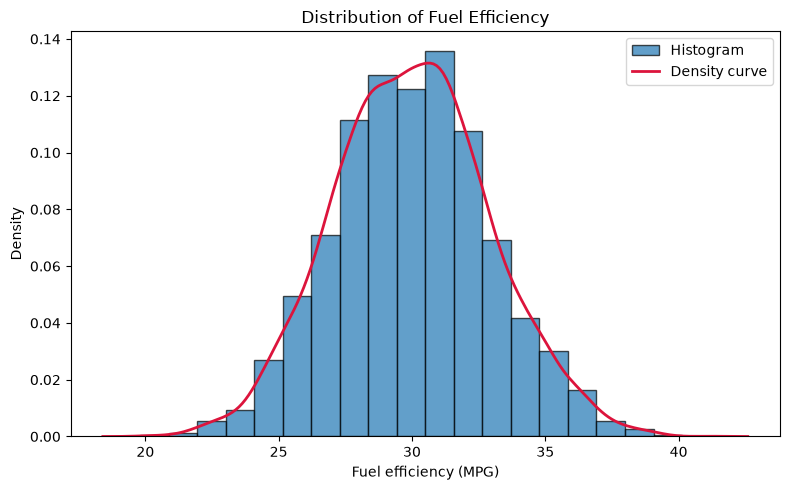

Skewness: 0.08
The distribution is approximately symmetric without a strong long tail.


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fuel_efficiency = df["fuel_efficiency_mpg"]
skewness = fuel_efficiency.skew()

plt.figure(figsize=(8, 5))
plt.hist(
    fuel_efficiency,
    bins=20,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Histogram",
)
sns.kdeplot(
    fuel_efficiency,
    color="crimson",
    linewidth=2,
    label="Density curve",
)
plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Density")
plt.title("Distribution of Fuel Efficiency")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Skewness: {skewness:.2f}")
if skewness > 0.5:
    print("The distribution is right-skewed with a longer right tail.")
elif skewness < -0.5:
    print("The distribution is left-skewed with a longer left tail.")
else:
    print("The distribution is approximately symmetric without a strong long tail.")

In [70]:
base_df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [109]:
import numpy as np

SEED = 42

n = len(df)
n_val = int(n * 0.20)
n_test = int(n * 0.20)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(SEED)
np.random.shuffle(idx)

df_shuffled = base_df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

X_train = df_train.drop(columns=["fuel_efficiency_mpg"])
X_val = df_val.drop(columns=["fuel_efficiency_mpg"])
X_test = df_test.drop(columns=["fuel_efficiency_mpg"])

y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [110]:
df_train.head() 

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [ ]:
def train_linear_regression(X, y):
    """ The ones column is a formatting trick. 
    It lets the model learn the intercept using 
    the exact same math it uses for every other weight, 
    instead of needing special handling — and that 
    intercept is what lets the line move up and down 
    to fit the data properly. """
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    """ Calculate the gram matrix (X^T * X) and its inverse.
    Then calculate the weights using the normal equation. """
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y_true, y_pred):
    """ Calculate the Root Mean Squared Error (RMSE) between true and predicted values. """
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [127]:
# horsepower has missing values - the normal equation returns NaN weights
# unless they are filled first.
X_train_0 = df_train.fillna(0)
X_val_0 = df_val.fillna(0)

w0, w = train_linear_regression(X_train_0, y_train)
y_pred_0 = w0 + X_val_0.dot(w)


In [128]:
y_pred_0, y_train

(0       30.4
 1       32.8
 2       27.8
 3       28.6
 4       31.1
         ... 
 1995    30.3
 1996    28.7
 1997    30.6
 1998    31.0
 1999    30.8
 Length: 2000, dtype: float64,
 array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,)))

In [129]:
mean_train = X_train.mean()
X_train_mean = df_train.fillna(mean_train)
X_val_mean = df_val.fillna(mean_train)

w0m, wm = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w0m + X_val_mean.dot(wm)

In [130]:
y_pred_mean, y_train

(0       30.4
 1       32.8
 2       27.8
 3       28.6
 4       31.1
         ... 
 1995    30.3
 1996    28.7
 1997    30.6
 1998    31.0
 1999    30.8
 Length: 2000, dtype: float64,
 array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,)))

In [131]:
rmse_0 = rmse(y_val, y_pred_0)
rmse_mean = rmse(y_val, y_pred_mean)

In [132]:
print(f"rmse_0: {rmse_0:.2f}")
print(f"rmse_mean: {rmse_mean:.2f}")

rmse_0: 0.00
rmse_mean: 0.00
